In [82]:
#imports
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

load_dotenv()


True

In [83]:
llm= ChatGroq(model='llama-3.3-70b-versatile')

In [84]:
#tools

search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_num: float, second_num,operation: str)->dict:
    '''bPerform a basic arithmetic operation on two numbers.
    Supported operations: add, subtract multipy, divide
    '''
    try :
        if operation == 'add':
            result= first_num + second_num
        elif operation == 'subtract':
            result= first_num - second_num   
        elif operation == 'multiply':
            result= first_num * second_num
        elif operation == 'divide':
            if second_num == 0:
                return {'error': 'Division by zero is not allowed'}
            result= first_num / second_num
        else:
            return {"error":f'''Unsupported operation '{operation}'. '''}
        
        return {'first_num':first_num,'second_num':second_num,'operation':operation,'result':result}
    except Exception as e:
        return {'error': str(e)}
    
@tool
def get_stock_price(symbol:str)-> dict:
    '''Fetch latest stock price for a given symbol (e.g. 'APPLE','TSLA)
    '''
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=compact&apikey=M85VVHL2AWBPYCBW"
    r=requests.get(url)
    return r.json()

In [85]:
#make tool list
tools= [get_stock_price,search_tool,calculator]

#Make the LLM tool-aware
llm_with_tools= llm.bind_tools(tools)

In [86]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [87]:
#graph nodes
def chat_node(state:ChatState):
    '''LLM node that may answer or request a tool call.'''
    messages= state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

tool_node = ToolNode(tools) #execute tool call



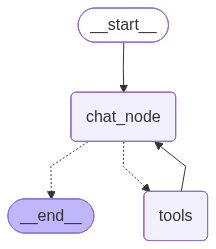

In [88]:
#Graph structure

graph= StateGraph(ChatState)

#node
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

#edges
graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')
# graph.add_edge('chat_node',END)
# graph.add_edge('tool',END)

chatbot=graph.compile()
chatbot

In [89]:
response= chatbot.invoke({'messages':[HumanMessage(content='hello')]})
print(response['messages'][-1].content)

I'm happy to chat with you, but I don't see a specific question or task that I can help with. Could you please provide more context or clarify what you would like to talk about? I can offer suggestions or ideas if you're unsure where to start.


In [90]:
response= chatbot.invoke({'messages':[HumanMessage(content='what is 4+3')]})
print(response['messages'][-1].content)

The answer to 4+3 is 7.


In [91]:
response= chatbot.invoke({'messages':[HumanMessage(content='what is the stock price of Apple')]})
print(response['messages'][-1].content)

The current stock price of Apple is $284.18.


In [92]:
response= chatbot.invoke({'messages':[HumanMessage(content='who is the parent company of youtube and what is its stock price')]})
print(response['messages'][-1].content)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=get_stock_price{"symbol": "GOOGL"}</function>\n'}}